# AP 155 Lab Exercise
---
## Exercise 2: Numbers, Subtractive Cancellation

_Instructions_: 
- **Report figure:** Two Figures (see *Problem 2: Rewriting functions...*) - Plot f(x) vs. x using the manual evaluation (the one with catastrophic cancellation) vs. the "better function". In each figure, show the area where the catastrophic cancellation occurs. There are two functions discussed in the exercise, hence two figures (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)
- **Report discussion:** Two Questions: 
    - (See Problem 1) Why do the "bad" and "good" formulas of the roots give out the values they do (what makes "good" good)? What led to the difference between the obtained values?
    - (See Problem 2) In each of the two functions discussed, for which values of x does the catastrophic cancellation occur (include here what the expected values were)? How were the catastrophic cancellations remedied? 
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Luarez, Karl Andrei
- _Student No._: 2024-12430
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

### Report figure
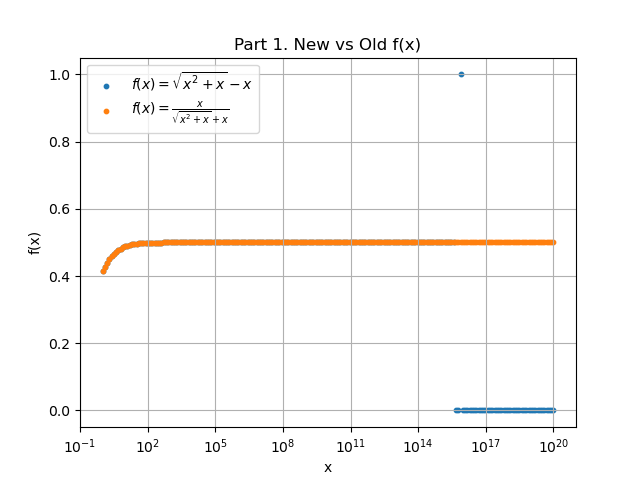 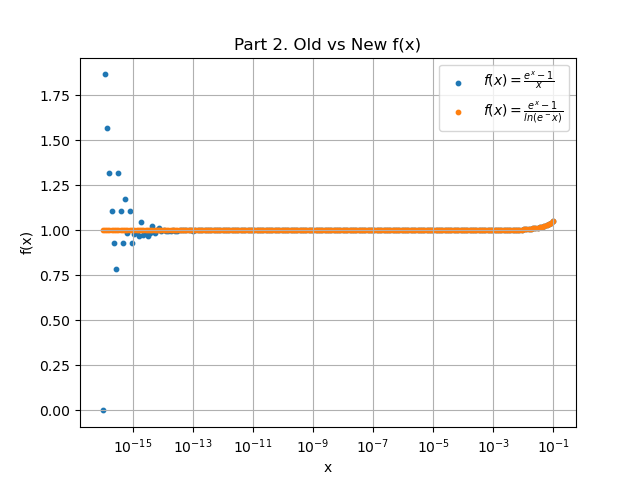

### Report discussion

For problem 1, evaluating the root using the original (bad) formula forces a subtraction of identical values for large values of b since $\sqrt{b^2-4ac} \approx b$, causing a catastrophic cancellation. The "good" formula avoids this by removing the subtraction in the formula, making sure that the positive root is evaluated without subtraction. For Problem 2, in $f(x) = \sqrt{x^2 + x} - x $, catastrophic cancellation occurs at large $x$, specifically starting at $x=10^15$. This was remedied by transforming $f(x)$ such that subtraction of similar values vanishes similar to the quadratic formula. For $f(x) = \frac{e^x - 1}{x}$, it occurs for values close to $x=0$. This was remedied by letting the denominator $x=ln(e^x)$ such that the round off error from the exponential function cancels out due to the division.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


## Section 2 (Problems and Code)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math as m

### Problem 1: Quadratic Equation (Gezerlis Problem 2.6)
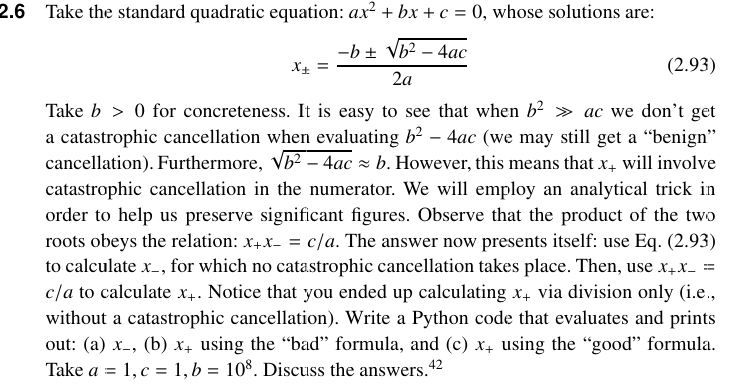

In [34]:
a = 1
b = 1e8
c = 1

def roots (a, b, c):
    discriminant = (b**2) - (4*a*c)

    if discriminant < 0:
        print("No real roots")
    else:
        xp_bad = (-b + m.sqrt(discriminant))/(2*a) #x+ using bad formula
        xm = (-b - m.sqrt(discriminant))/(2*a) #x- using bad formula
        xpxm = c/a
        xp_good = xpxm/xm# x+ using good formula

        return print(f"xminus = {xm}", f"xplus bad = {xp_bad}", f"xplus good = {xp_good}", sep="\n")

In [35]:
roots(a,b,c)

xminus = -100000000.0
xplus bad = -7.450580596923828e-09
xplus good = -1e-08


#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

The script evaluates the roots of the quadratic equation using the quadratic formula in Eq. (2.93). Noticeably, there is a catastrophic cancellation for large values of b for the $x_+$ root because of subtraction of almost identical values. Since the $x_{-}$ has no catastrophic cancellation, we use it to compute for $x_{+}$, this vanishes subtraction thus resulting to no catastrophic cancellation.


### Problem 2: Rewriting Functions to avoid subtractive cancellation

### Part 1: $ f(x) = \sqrt{x^2 + x} - x $

Consider the function 
$$ f(x) = \sqrt{x^2 + x} - x $$

- For which values of x does the catastrophic cancellation occur?
    - For large $x$, $\sqrt{x^2+x} \approx x$, therefore catastrophic cancellation occurs for large $x$ since we will be subtracting two almost identical values
- How can we rewrite the function to avoid catastrophic cancellation?
    - Rationalizing $f(x)$ so that we can avoid subtracting identical numbers:
  $\sqrt{x^2+x} - x \cdot \frac{\sqrt{x^2+x}+x}{\sqrt{x^2+x}+x} = \frac{x}{\sqrt{x^2+x}+x}$
- [FIGURE] Plot f(x) vs. x using the manual evaluation vs. the rewritten function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)

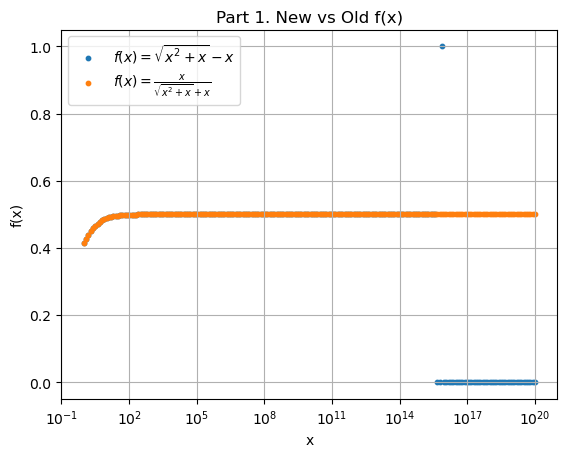

In [24]:
# Old f(X)
def f(x):
    return np.sqrt(x**2 + x) - x

# New f(x)
def new_f(x): #new f(x)
    return x/(np.sqrt(x**2+x)+x)

x = np.logspace(0, 20, 200)
y_old = f(x)
y_new = new_f(x)

plt.title("Part 1. New vs Old " r"f(x)")
plt.xlabel('x')
plt.ylabel('f(x)')
plt.scatter(x, y_old, s=10, label=r"$f(x) = \sqrt{x^2+x}-x$")
plt.scatter(x, y_new, s=10, label=r"$f(x)=\frac{x}{\sqrt{x^2+x}+x} $")
plt.xscale('log')
plt.legend(loc='upper left')
plt.grid()
plt.show
plt.savefig('Problem2.1.png')

#### Part 2: $ f(x) = \frac{e^x - 1}{x}$

Consider the function 
$$ f(x) = \frac{e^x - 1}{x}$$

- For which values of x does the catastrophic cancellation occur?
    - As $x \rightarrow 0, e^x \rightarrow 1$, therefore the numerator becomes a subtraction of similar values and catastrophic cancellation occurs. The denominator also approaches zero resulting in an indeterminate form $\frac{0}{0}$,another catastrophic calculation.
- How can we resolve the catastrophic cancellation?
    - Consider the substitution w=np.exp(x) ($w=e^x$), noting that $ln(e^x)=x=ln(w)$, the new function becomes $f(w)=\frac{w-1}{ln(w)}$. This prevents a catastrophic cancellation because the exponential function appears in both the numerator and denominator,making the round-off error cancel out because of the division.
- [FIGURE] Plot the f(x) vs. x using the manual evaluation vs. the numpy special function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)



In [6]:
# x = ln(1), x = 0 
# note as x --> 0 , f(x) --> 1

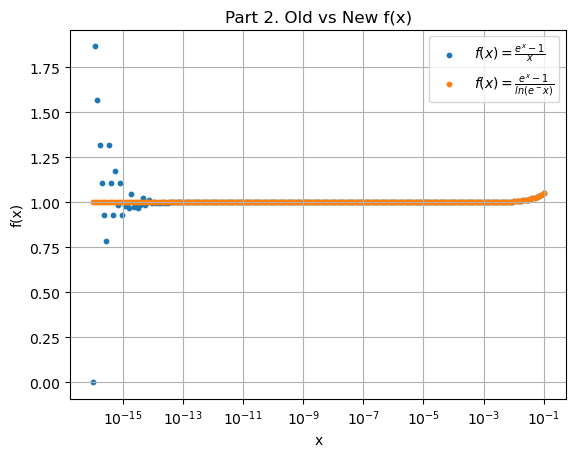

In [28]:
# Old f(x)
def naive_f(x):
    return (np.exp(x) - 1)/x 

# New f(x)
def new_f(x):
    results = np.zeros_like(x)
    for i, z in enumerate(x):
        w = np.exp(z)
        if w == 0:
            results[i] = -1 / z
        elif w == 1:
            results[i] = 1
        else:
            results[i] = (w-1) / np.log(w)
    return results
    
x = np.logspace(-16, -1, 200)
y1 = naive_f(x)
y2 = new_f(x)

plt.title("Part 2. Old vs New " r"f(x)")
plt.xlabel('x')
plt.ylabel('f(x)')
plt.scatter(x, y1, s=10, label=r'$f(x) = \frac{e^x - 1}{x} $')
plt.scatter(x, y2, s=10, label=r'$f(x)= \frac{e^x - 1}{ln(e^-x)}$')
plt.xscale('log')
plt.legend()
plt.grid()
plt.show
plt.savefig('Problem 2.2.png')

#### Problem 2 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

The script for Parts 1 and 2 of Problem 2 transforms the erroneous function with catastrophic cancellations into one that doesn't have one. Then, the old and new functions are plotted over some range x near the values where catastrophic cancellations arise from the original function. Then, a plot is generated to compare the the behavior of unstable and stable functions.

## Section 3 (Notes)

### Floating-point representation
Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [8]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

0.30000000000000004
0.30000000000000001665
0.2998
0.3000000000000000166533453694
0.3
